In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("AmesHousing.csv")
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [3]:
df.isna().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [4]:
df.drop(columns = ["PID","Order"], inplace = True)
df = df[df['Gr Liv Area'] < 3500]

In [5]:
dfs = df.drop(columns = df.select_dtypes("number").columns.tolist())
dfn = df.select_dtypes("number")

In [6]:
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0, np.nan: 0}
expo_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'NA': 0, np.nan: 0}
bsmt_fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'NA': 0, np.nan: 0}
garage_fin_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'NA': 0, np.nan: 0}
shape_map = {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1, np.nan: 0}
slope_map = {'Gtl': 3, 'Mod': 2, 'Sev': 1, np.nan: 0}
util_map = {'AllPub': 4, 'NoSewr': 3, 'NoSeWa': 2, 'ELO': 1, np.nan: 0}
func_map = {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0, np.nan: 7}
paved_map = {'Y': 2, 'P': 1, 'N': 0, np.nan: 0}
fence_map = {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'NA': 0, np.nan: 0}

qual_cols = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond', 'Heating QC', 'Kitchen Qual', 'Fireplace Qu', 'Garage Qual', 'Garage Cond', 'Pool QC']

for col in qual_cols:
    dfs[col] = dfs[col].map(qual_map)

mappings = {
    'Bsmt Exposure': expo_map,
    'BsmtFin Type 1': bsmt_fin_map,
    'BsmtFin Type 2': bsmt_fin_map,
    'Garage Finish': garage_fin_map,
    'Lot Shape': shape_map,
    'Land Slope': slope_map,
    'Utilities': util_map,
    'Functional': func_map,
    'Paved Drive': paved_map,
    'Fence': fence_map
}

for col, mapping in mappings.items():
    dfs[col] = dfs[col].map(mapping)

In [7]:
for col in dfs.select_dtypes("number").columns:
    dfn[col] = dfs[col]
    dfs.drop(columns = col, inplace = True)
dfs = pd.get_dummies(dfs, dtype = int)

In [8]:
dff = pd.concat([dfs, dfn], axis=1)

In [9]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=2)
cools = dff.columns
dff = imputer.fit_transform(dff)
dff = pd.DataFrame(dff, columns = cools)

In [10]:
df_50 = pd.DataFrame()
for col in dff.columns:
    if df["SalePrice"].corr(dff[col])>= 0.5:
        df_50[col] = dff[col]
display(df_50.info())

<class 'pandas.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Overall Qual   2920 non-null   float64
 1   Year Built     2920 non-null   float64
 2   Total Bsmt SF  2920 non-null   float64
 3   Gr Liv Area    2920 non-null   float64
 4   Garage Yr Blt  2920 non-null   float64
 5   Garage Cars    2920 non-null   float64
 6   Garage Area    2920 non-null   float64
 7   SalePrice      2920 non-null   float64
 8   Exter Qual     2920 non-null   float64
 9   Bsmt Qual      2920 non-null   float64
 10  Kitchen Qual   2920 non-null   float64
dtypes: float64(11)
memory usage: 251.1 KB


None

In [11]:
def drop_redundant_features_dynamic(df, target_col):
    corr = df.corr(numeric_only=True).abs()

    target_corr = corr[target_col].drop(target_col)
    cols = [c for c in corr.columns if c != target_col]

    to_drop = set()

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            c1, c2 = cols[i], cols[j]

            if c1 in to_drop or c2 in to_drop:
                continue

            pair_corr = corr.loc[c1, c2]
            c1_target = target_corr[c1]
            c2_target = target_corr[c2]

            # Drop if the two features are more correlated with each other
            # than either is with the target
            if pair_corr > c1_target and pair_corr > c2_target:
                if c1_target < c2_target:
                    to_drop.add(c1)
                else:
                    to_drop.add(c2)

    reduced_df = df.drop(columns=list(to_drop))
    return reduced_df

In [12]:
red_df = drop_redundant_features_dynamic(df_50, "SalePrice")

In [13]:
df_50 

,Overall Qual,Year Built,Total Bsmt SF,Gr Liv Area,Garage Yr Blt,Garage Cars,Garage Area,SalePrice,Exter Qual,Bsmt Qual,Kitchen Qual
0,6.0,1960.0,1080.0,1656.0,1960.0,2.0,528.0,215000.0,3.0,3.0,3.0
1,5.0,1961.0,882.0,896.0,1961.0,1.0,730.0,105000.0,3.0,3.0,3.0
2,6.0,1958.0,1329.0,1329.0,1958.0,1.0,312.0,172000.0,3.0,3.0,4.0
3,7.0,1968.0,2110.0,2110.0,1968.0,2.0,522.0,244000.0,4.0,3.0,5.0
4,5.0,1997.0,928.0,1629.0,1997.0,2.0,482.0,189900.0,3.0,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...
2915,6.0,1984.0,1003.0,1003.0,1984.0,2.0,588.0,142500.0,3.0,3.0,3.0
2916,5.0,1983.0,864.0,902.0,1983.0,2.0,484.0,131000.0,3.0,4.0,3.0
2917,5.0,1992.0,912.0,970.0,1962.5,0.0,0.0,132000.0,3.0,4.0,3.0
2918,5.0,1974.0,1389.0,1389.0,1975.0,2.0,418.0,170000.0,3.0,4.0,3.0


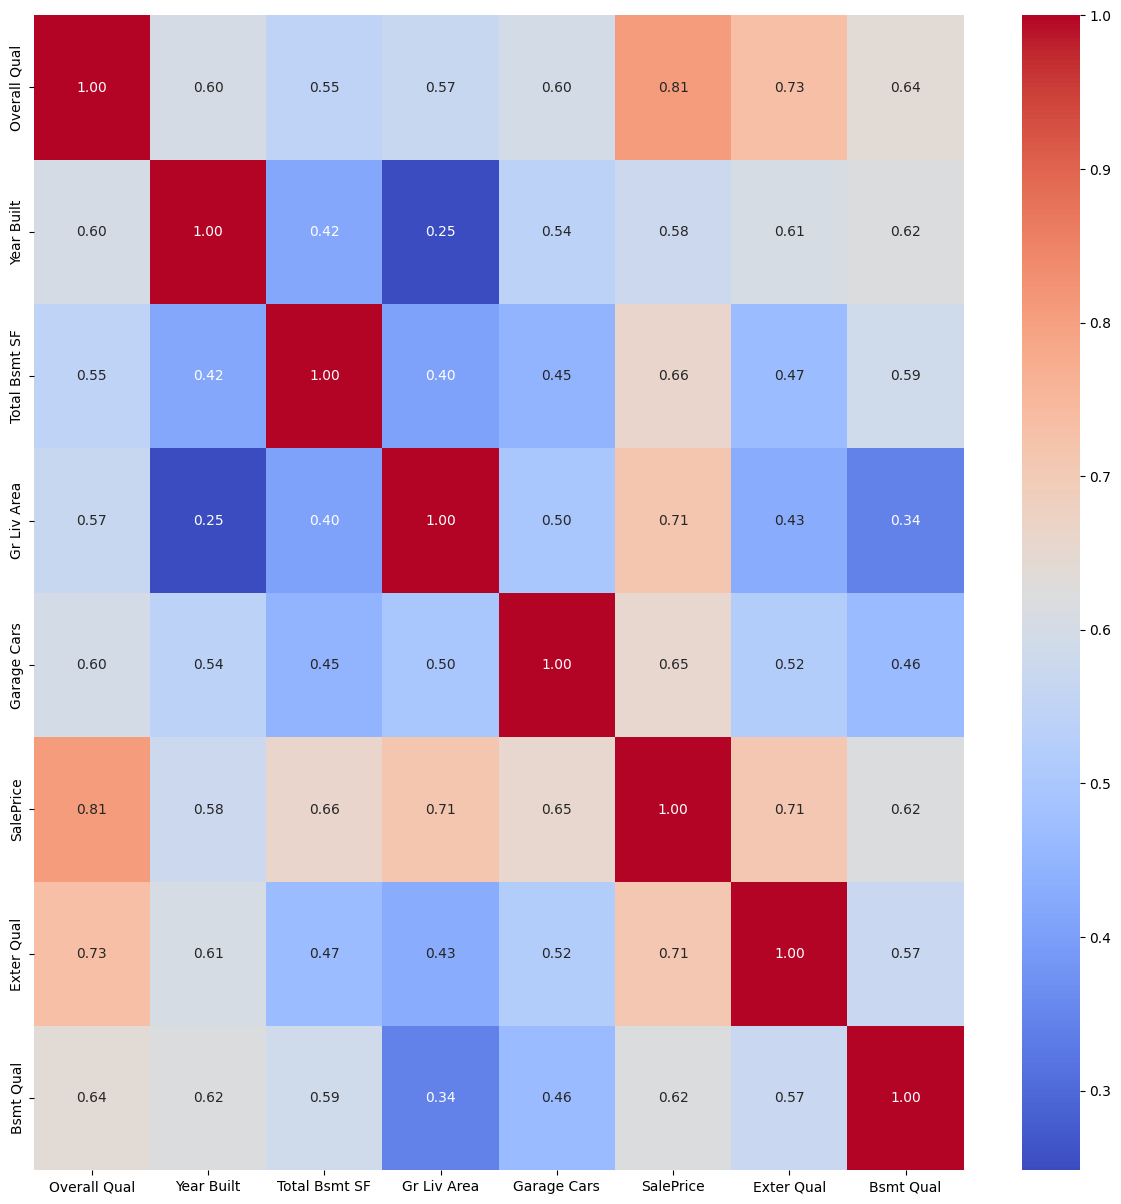

In [14]:
plt.figure(figsize=(15, 15))
sns.heatmap(red_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [15]:
x = red_df.drop(columns = "SalePrice")
y = red_df["SalePrice"]

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y,train_size=0.8 , random_state = 42)

In [17]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
feature_scaler = make_pipeline(MinMaxScaler(), LinearRegression())
model = TransformedTargetRegressor(
    regressor=feature_scaler,
    func=np.log1p,
    inverse_func=np.expm1
)

model.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...egression())])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [18]:
import joblib
joblib.dump(model, 'HouseWizard.joblib')

['HouseWizard.joblib']

In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae}")
print('Mean_Squared_Error :' ,mse)
print('Root_Mean_Squared_Error :' ,rmse)
print('r_square_value :',r_squared)

MAE: 18533.288338113263
Mean_Squared_Error : 735197044.6881955
Root_Mean_Squared_Error : 27114.517231331916
r_square_value : 0.8994314459610205


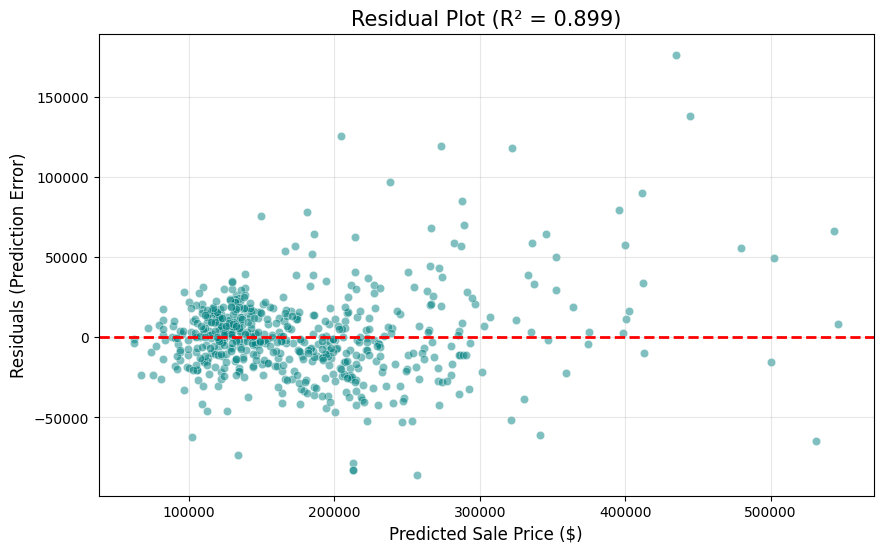

In [21]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='teal')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Residual Plot (R² = 0.899)', fontsize=15)
plt.xlabel('Predicted Sale Price ($)', fontsize=12)
plt.ylabel('Residuals (Prediction Error)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [22]:
from sklearn.model_selection import KFold, cross_val_score
kf = KFold(n_splits = 5, shuffle=True, random_state=1)
scores = cross_val_score(model, x, y, cv=kf, scoring='r2')
print(f"Shuffled Average R2: {scores.mean():.4f}")
print(f"Shuffled Std Dev: {scores.std():.4f}")
print(cross_val_score(model, x, y, cv=kf, scoring = 'r2'))

Shuffled Average R2: 0.8811
Shuffled Std Dev: 0.0084
[0.8975069  0.87485168 0.87793279 0.88014882 0.8751127 ]
